In [1]:
import sys
!{sys.executable} -m pip install numpy matplotlib

  Using cached numpy-2.4.6-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.4.6-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached matplotlib-3.11.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (11.1 MB)
Using cached contourpy-1.

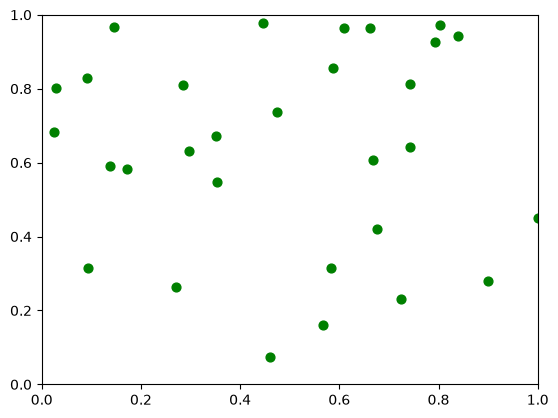

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
# import sys
# print(sys.executable)
# ------------------
# Parameters
# 

N = 30
Lx = 1.0
Ly = 1.0

dt = 0.01

# ------------------
# Initial conditions
# ------------------

x = np.random.rand(N) * Lx
y = np.random.rand(N) * Ly

vx = np.random.uniform(-1, 1, N)
vy = np.random.uniform(-1, 1, N)

# ------------------
# Plot
# ------------------

fig, ax = plt.subplots()

ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)

scat = ax.scatter(x, y, s=40, color='green')

# ------------------
# Time stepping
# ------------------

def update(frame):

    global x, y, vx, vy

    x += vx * dt
    y += vy * dt

    # wall reflections

    hit_left = x < 0
    hit_right = x > Lx

    vx[hit_left | hit_right] *= -1

    x = np.clip(x, 0, Lx)

    hit_bottom = y < 0
    hit_top = y > Ly

    vy[hit_bottom | hit_top] *= -1

    y = np.clip(y, 0, Ly)

    scat.set_offsets(np.column_stack((x, y)))

    return scat,

ani = FuncAnimation(
    fig,
    update,
    frames=100,
    interval=10,
    blit=True
)

from IPython.display import HTML

HTML(ani.to_jshtml())